# Time Series Analysis

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

## a) Exploration

### i)

In [2]:
masterDF = pd.read_csv("time-series/air_traffic.csv")

## Preprocess all numbers into ints
for column in masterDF.columns:
    if masterDF[column].astype(str)[0].__contains__(","):
        masterDF[column] = [int(x.replace(",","")) for x in masterDF[column].astype(str)]

sortedMasterDF = masterDF.sort_values(["Year", "Month"])
print("Time range: From " + str(sortedMasterDF["Month"][0]) + "/" + str(sortedMasterDF["Year"][0])+ " to " + str(sortedMasterDF["Month"][len(masterDF)-1])+ "/" + str(sortedMasterDF["Year"][len(masterDF)-1]))
print("Months tracked: " + str(len(masterDF)))
print("Amount of flights: " + str(masterDF["Flt"].astype(int).sum()))


Time range: From 1/2003 to 9/2023
Months tracked: 249
Amount of flights: 192100234


### ii)

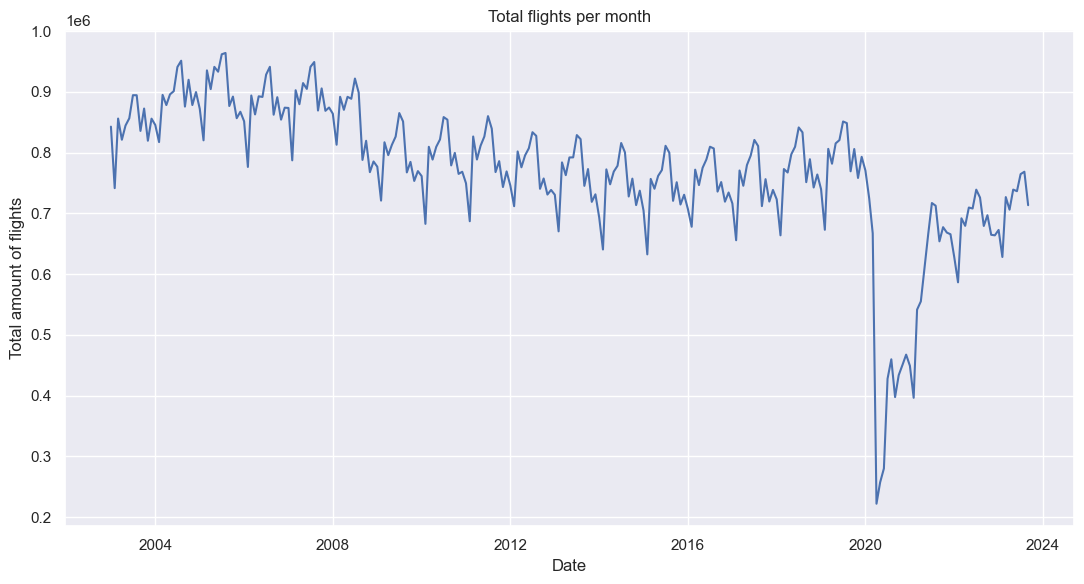

In [3]:
timeSeriesDF = masterDF.copy()
timeSeriesDF["Day"] = 1
timeSeriesDF["Date"] = pd.to_datetime(timeSeriesDF[["Day", "Month", "Year"]])

sns.set_theme()
fig, ax = plt.subplots(figsize=(11,6))
ax = sns.lineplot(timeSeriesDF, x="Date", y="Flt")
#plt.xticks(rotation=90)
ax.set_title("Total flights per month")
ax.set_ylabel("Total amount of flights")
plt.tight_layout()

We see an overall seasonality in the demand for flights, a slight downward trend in the 2010s and a high collapse in the number of flights during the COVID-19 pandemic.

### iii)

Text(0.5, 1.0, 'Timeseries of total flights and total passengers')

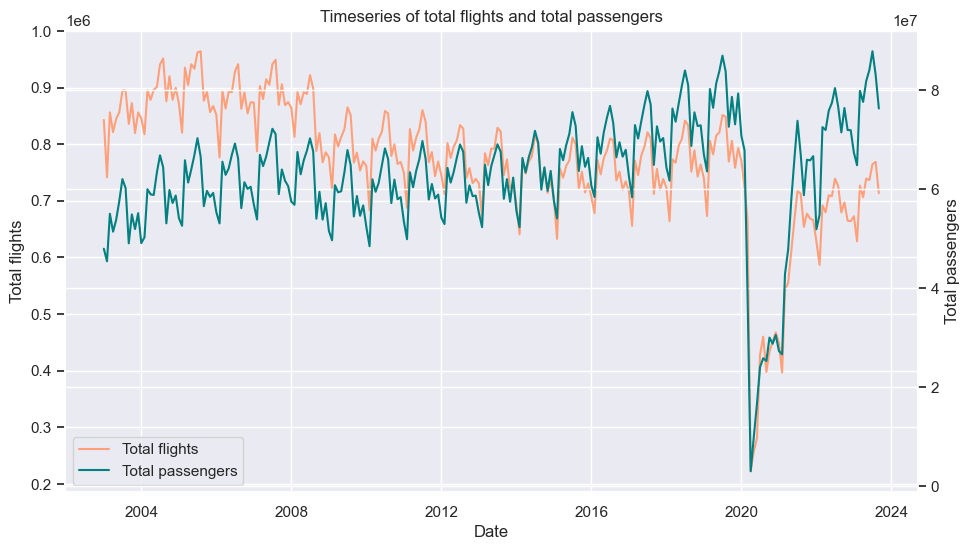

In [25]:
fig, ax = plt.subplots(figsize=(11,6))

# Plot first line and get the line object
line1, = ax.plot(timeSeriesDF["Date"], timeSeriesDF["Flt"], color="lightsalmon", label="Total flights")

ax.set_xlabel("Date")
ax.set_ylabel("Total flights")

ax_sec = ax.twinx()
ax_sec.set_ylabel("Total passengers")

# Plot second line and get the line object
line2, = ax_sec.plot(timeSeriesDF["Date"], timeSeriesDF["Pax"], color="teal", label="Total passengers")

# Create a combined legend
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='lower left')

ax.set_title("Timeseries of total flights and total passengers")

The development of passengers follows a similar pattern to that of flights. However, it is visible that while a general downward trend in number of flights is seen, this is not present in the number of passengers. This indicates that demand for flights has not gone down, but plane size or utilization of planes has increased.

## b) Investigation
### i)

Text(0.5, 1.0, 'Yearly amount of passengers')

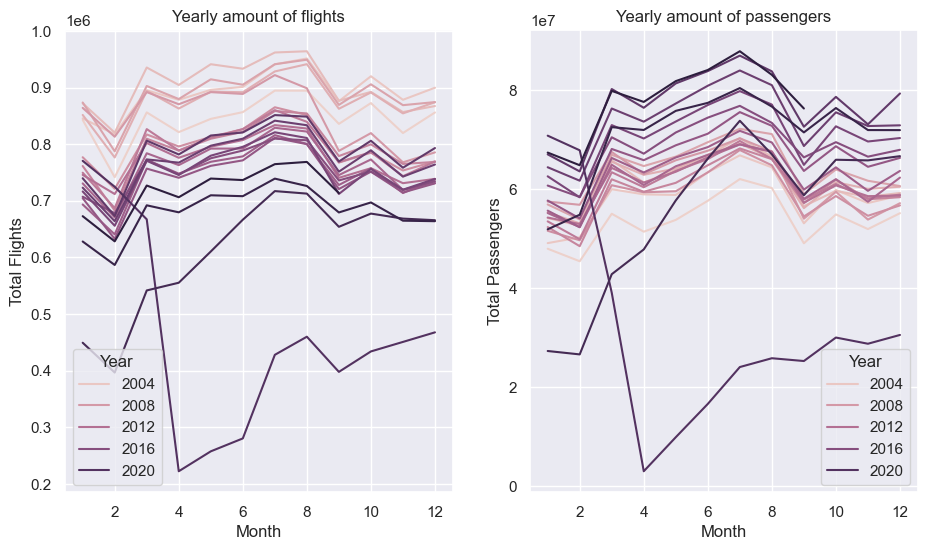

In [29]:
fig, axs = plt.subplots(ncols=2, figsize=(11,6))
plt.sca(axs[0])
sns.lineplot(timeSeriesDF,x="Month", y="Flt", hue="Year")
axs[0].set_ylabel("Total Flights")
axs[0].set_title("Yearly amount of flights")
plt.sca(axs[1])
sns.lineplot(timeSeriesDF,x="Month",y="Pax",hue="Year")
axs[1].set_ylabel("Total Passengers")
axs[1].set_title("Yearly amount of passengers")

There are seasonal effects with a general increase in the warmer months. 2020 does not follow this trend, probably caused by the pandemic.

### ii)

In [6]:
correlationFactor = timeSeriesDF["Flt"].corr(timeSeriesDF["Pax"])
print("Correlation Factor: " + str(correlationFactor))

Correlation Factor: 0.5698387345242093


The correlation factor is 0.57, which is positive. This indicates a slight positive correlation between both datasets.

### iii)

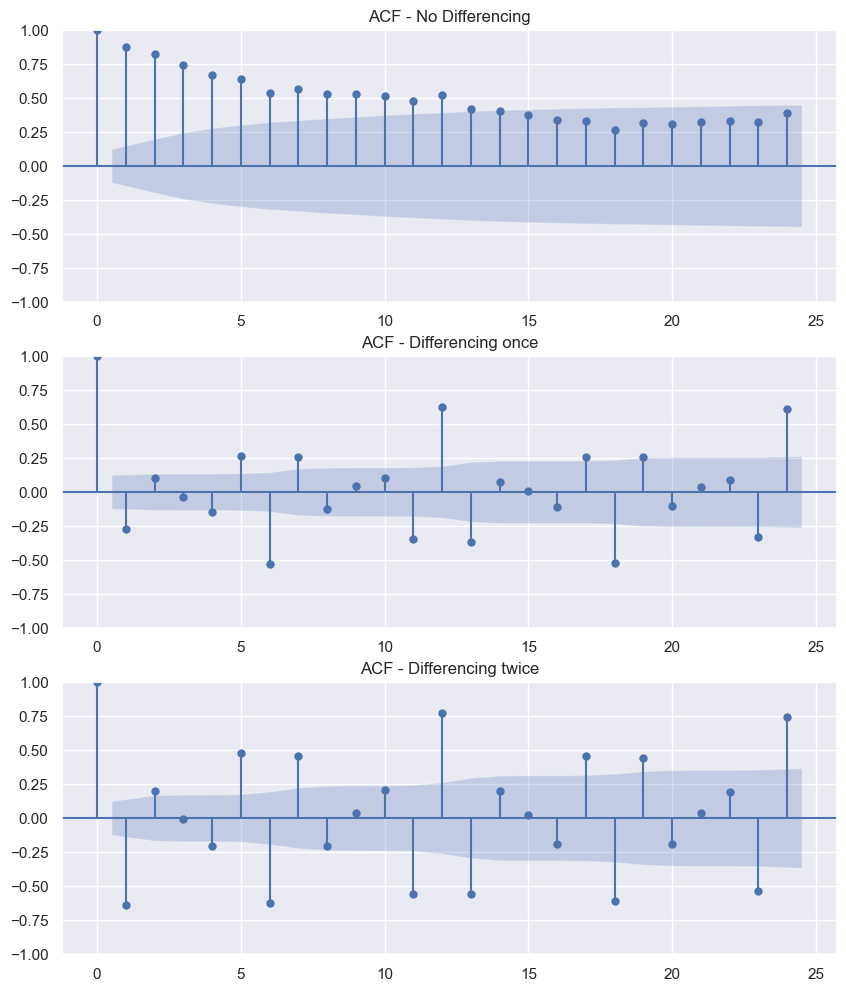

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axs = plt.subplots(3, 1, figsize=(10, 12))
plot_acf(timeSeriesDF["Flt"], lags=24, ax=axs[0], title="ACF - No Differencing")
plot_acf(timeSeriesDF["Flt"].diff().dropna(), lags=24, ax=axs[1], title="ACF - Differencing once")
plot_acf(timeSeriesDF["Flt"].diff().diff().dropna(), lags=24, ax=axs[2], title="ACF - Differencing twice")

plt.show()

### iv)

In [8]:
from statsmodels.tsa.seasonal import STL

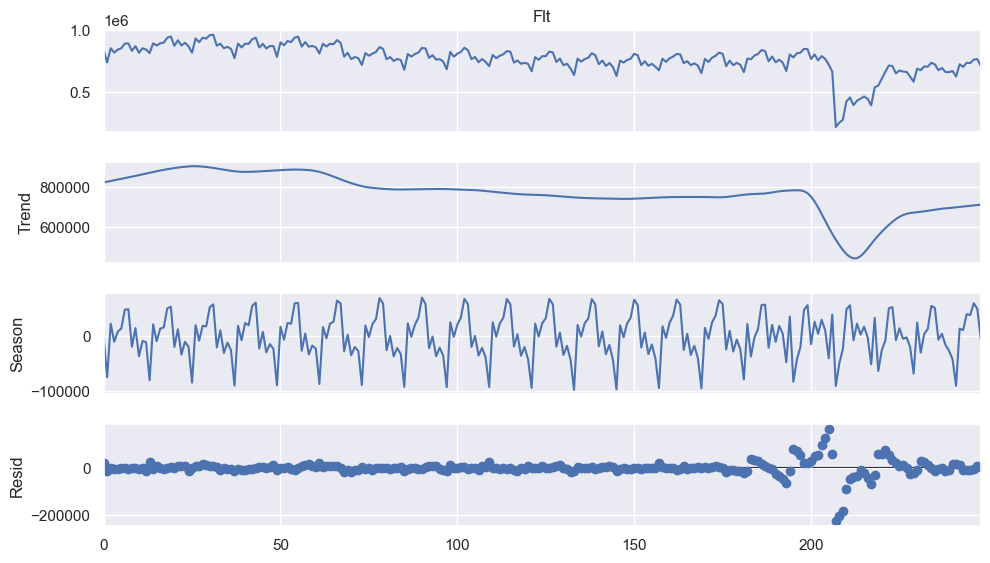

In [9]:
stl = STL(timeSeriesDF["Flt"], period=12)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(11,6)
plt.show()

## c) Forecasting


### i)

The strong seasonality of the data makes it suitable for prediction. However, the uncharacteristic break in 2020 due to the pandemic may prove an obstacle in the training data.

In [10]:
from sktime.forecasting.arima import StatsModelsARIMA
from sktime.forecasting.naive import NaiveForecaster
from sktime.performance_metrics.forecasting import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [31]:
trainset = pd.read_csv("time-series/flights_train.csv")
testset = pd.read_csv("time-series/flights_test.csv")

naive = NaiveForecaster("mean")

naive = naive.fit(trainset["Flt"])
naive_pred = naive.predict(range(1,len(testset)+1))

# Extract the actual values
y_test = testset["Flt"]

# Calculate Metrics
rmse_naive = mean_squared_error(y_test, naive_pred, square_root=True)
mae_naive = mean_absolute_error(y_test, naive_pred)
mape_naive = mean_absolute_percentage_error(y_test, naive_pred)

# Display results
print("Naive forecaster:")
print("RMSE:\t"+str(rmse_naive.__round__(2)))
print("MAE:\t"+str(mae_naive.__round__(2)))
print("MAPE:\t"+str(mape_naive.__round__(2)))

betterValueFound = False

# Perform a grid search over the three values for p d and q
for p in range(1,10):
    for d in range(3):
        for q in range(12):
            arima = StatsModelsARIMA(order=(p,d,q))
            arima = arima.fit(trainset["Flt"])
            arima_pred = arima.predict(range(1,len(testset)+1))

            # Calculate Metrics
            rmse_arima = mean_squared_error(y_test, arima_pred, square_root=True)
            mae_arima = mean_absolute_error(y_test, arima_pred)
            mape_arima = mean_absolute_percentage_error(y_test, arima_pred)

            # Display results
            print("Arima forecaster:")
            print("RMSE:\t"+str(rmse_arima.__round__(2)))
            print("MAE:\t"+str(mae_arima.__round__(2)))
            print("MAPE:\t"+str(mape_arima.__round__(2)))

            if rmse_arima < rmse_naive and mae_arima < mae_naive and mape_arima < mape_naive:
                print("Better values found!")
                print(p)
                print(d)
                print(q)
                betterValueFound = True
                break
        if betterValueFound:
            break
    if betterValueFound:
        break

Naive forecaster:
RMSE:	51192.1
MAE:	36663.86
MAPE:	0.05
Arima forecaster:
RMSE:	43464.06
MAE:	33692.37
MAPE:	0.04
Better values found!
1
0
0


c:\Users\jonaw\miniconda3\envs\ids_env\Lib\site-packages\skbase\base\_base.py:1342: FutureWarning: tag 'handles-missing-data' will be removed in sktime version 1.0.0 and replaced by 'capability:missing_values', please use 'capability:missing_values' instead
  self._deprecate_tag_warn(collected_tags)


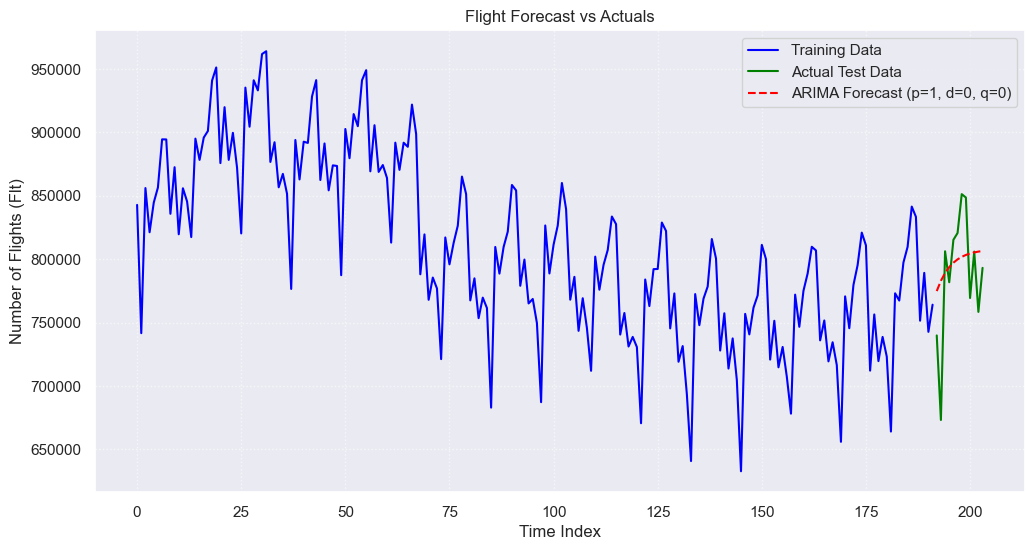

In [32]:
testsetIndex = testset.index+len(trainset)

plt.figure(figsize=(12, 6))
plt.plot(trainset.index, trainset["Flt"], label="Training Data", color="blue")
plt.plot(testsetIndex, testset["Flt"], label="Actual Test Data", color="green")
plt.plot(testsetIndex, arima_pred, label=f"ARIMA Forecast (p={p}, d={d}, q={q})", 
         color="red", linestyle="--")
plt.title("Flight Forecast vs Actuals")
plt.xlabel("Time Index")
plt.ylabel("Number of Flights (Flt)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

The prediction is very loosely based on the underlying data.

In [30]:
arima_pred

192    764479.805318
193    782962.022888
194    807966.572916
195    807966.572916
196    807966.572916
197    807966.572916
198    807966.572916
199    807966.572916
200    807966.572916
201    807966.572916
202    807966.572916
203    807966.572916
Name: Flt, dtype: float64